# **Who**: David

## **Task**: find out what phrases/keywords are important for the positively annotated class with respect to the negatives.

Ingredients:
* simply word frequencies: first remove stopwords and extract the word counts (use sklearn's CountVectorizer perhaps), maybe do this per section of the text
* use Jacopo's models in combination with a tool like LIME or SHAP.
* aggregate the embeddings of the medical terms in the texts 

In [1]:
import pandas as pd

import string

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer

import matplotlib.pyplot as plt

from scipy import stats

import numpy as np

In [2]:
# Necessary resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ddellamo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ddellamo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ddellamo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df_consults = pd.read_sas(
    r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240822\consult_20240822.sas7bdat',
        encoding='latin1')

df_consults = df_consults.drop(['Consult_id', 'ConsultStatus', 'type_code_original',
    'type_display_original','created', 'title', 'author_usercode',
    'initial_author_usercode', 'custodian_Organization_value',
    'SpecialismeNaam', 'initial_custodian_Organization_v',
    'SpecialismeNaamInitial', 'LocationCode', 'LocationName',
    'PatientProtected', 'section_title_code_original',
    'section_title_display_original', 'section_text',
    'section_text_contentType', 'orderedBy', 'index_date'],
    axis='columns')

df_consults = df_consults.groupby('studyId_0831').last()

df_consults_text = pd.read_parquet(r"T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240826\consult_texts.parquet")

df_merged = pd.merge(df_consults_text, df_consults, right_index=True,left_on='studyId_0831',how='left')

In [4]:
df_merged['delta'] = (df_merged.date_x - df_merged.date_y).dt.days

df_merged_filt = df_merged.query('delta >= -365 and delta <= 0')

In [5]:
# Funzione per ottenere il testo più lungo e il rispettivo delta
def longest_text(group):
    longest = group.loc[group['text'].str.len().idxmax()]
    return pd.Series({
        'text': longest['text'],
        'delta': longest['delta']
    })

In [6]:
# Raggruppa per patient_id e applica la funzione
df_merged_f_g = df_merged_filt.groupby('studyId_0831').apply(longest_text, include_groups=False)

In [7]:
df_afsprak = pd.read_sas(
    r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240805\afspraken_20240805.sas7bdat',
        encoding='latin1')

df_afsprak.studyId_0831 = df_afsprak.studyId_0831.astype('uint64')

df_afsprak = df_afsprak.filter(items=['studyId_0831', 'index_AfspCode'])

df_afsprak = df_afsprak.groupby('studyId_0831', sort=True).agg(lambda x: x.to_list())

In [8]:
def isEligible(x:pd.Series):
    if 'NFALG' in x or 'NFGEH' in x or 'NFVMI+' in x or 'NFVAL+' in x:
        return 1
    else:
        return 0

In [9]:
df_afsprak['label'] = df_afsprak.index_AfspCode.apply(isEligible)

df_afsprak = df_afsprak[['label']]

df_afsprak

,label
studyId_0831,
7992019,1
9812359,0
22291801,0
29822615,0
42120023,0
...,...
67374258279,1
67384735347,1
67387668117,0


In [10]:
df_afsprak = df_afsprak.groupby('studyId_0831').last()

In [11]:
df_cons_afs = pd.merge(df_merged_f_g, df_afsprak, 
    right_index=True, left_on='studyId_0831', how='left')

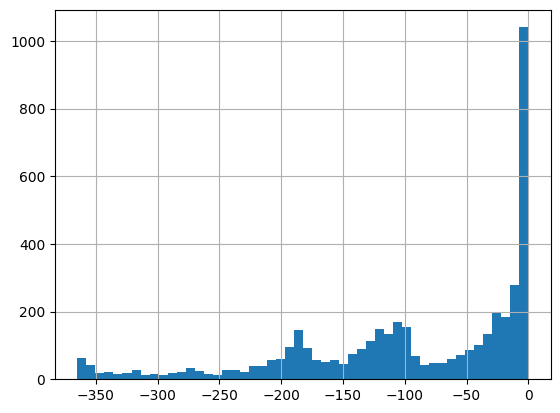

In [12]:
plt.figure()
plt.show(df_cons_afs['delta'].hist(bins=50))

In [13]:
df_cons_afs['text'].str.split().str.len().sort_values(ascending=False)

studyId_0831
43804529669    2886
62746771965    2760
19226454055    2663
669456381      2661
4112676685     2657
               ... 
1153774693       41
1222394769       40
64989761203      40
18185826355      39
13003729637      37
Name: text, Length: 4431, dtype: int64

### Stopwords and numbers removal from the consults dataset

In [ ]:
# Rimuovi tutti i numeri dal testo
df_cons_afs['text'] = df_cons_afs['text'].str.replace(r'\d+', '', regex=True)

# Carica le stopwords per la lingua olandese
stop_words = stopwords.words('dutch')

In [ ]:
# Funzione per rimuovere stopwords e punteggiatura
def remove_stopwords(text):
    # Rimuovere punteggiatura
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Rimuovere stopwords e convertire in minuscolo
    text = ' '.join([word for word in text.lower().split() if word not in stop_words])
    
    return text

In [ ]:
# Applica la funzione al testo
df_cons_afs['clean_text'] = df_cons_afs['text'].apply(remove_stopwords)

# Contare le parole in ciascun testo
df_cons_afs['word_count'] = df_cons_afs['clean_text'].str.split().str.len()

# Ordinare il DataFrame in base al conteggio delle parole
df_cons_afs = df_cons_afs.sort_values(by='word_count')

In [17]:
result = df_cons_afs['clean_text'].str.split().str.len().sort_values(ascending=False)

print(result.to_string(index=True))

studyId_0831
43804529669    1905
4112676685     1756
62746771965    1746
19226454055    1731
669456381      1730
4368259163     1701
7553328287     1690
5356831881     1634
24191026885    1618
23550435755    1595
23170301569    1595
34653801845    1572
65049717809    1560
56476179347    1550
51484051963    1521
10688870679    1503
13591328647    1495
34709005341    1490
14673783715    1477
65236424015    1470
41767683823    1468
24735443385    1459
25062019123    1458
29974132451    1457
16722852807    1456
16033361951    1455
49124810419    1450
964688561      1444
10050571829    1444
4086598629     1435
58713451369    1432
60592689481    1428
27431164665    1424
3290638109     1422
36985738289    1416
21053623701    1411
21602705665    1400
1091856165     1377
730896227      1377
2622492425     1377
44724900315    1373
38370679929    1371
13941845227    1369
919078931      1365
52016123861    1364
40991106553    1358
7187992791     1358
745398269      1358
61262891475    1357
1636970

In [18]:
Id = 43804529669

'''
print(df_merged_f_g.loc[Id, 'text'].split())
print('')
print(df_merged_f_g.loc[Id, 'clean_text'].split())
print('')
print(df_merged_f_g.loc[Id, 'clean_text'])
print('')
'''
print(df_cons_afs.loc[Id, 'clean_text'])

specialismenaam geriatrie onderwerp polikliniek eerste consult titel beloop inhoudger consult geriatrie keuzelijst polikliniek eerste consult datum tijd datum tijd zetten reden komst huisarts syndroom fahr begrepen radioloishe diagnose toe benaderd solkchron pijnsyndroom pt ten einde raad inmiddels euthanasieverzoek neergelegd hoofdsymptoom pijn verkrampingen hele lichaam neuroloog prick verwezen neurologie prof groningen laardie snel mee klaar vraag diagnose ueberhaubt bestaat opties samenvatting bijwerken samenvatting voorgeschiedenis burnout sterilisatie hypertensie oesofagale reflux astma osas wv cpap polyartrose reumatoïde artritis frozen shoulder restless legs neuropathieradiculaire cwkchronisch pijnsyndroom revalidatiearts chronische vermoeidheid positieve revalidatie euthanasieverklaring moechronisch pijnsyndroom cataract glasvochtloslating os iatrogeen perifeer oedeem naproxen pijnarts ivm cervicobrachialgie links welke reageert pijnbehandeling oa tens butrans lyrica sinds jaa

### Word Frequency Analysis

Devo fare riferimento a https://docs.scipy.org/doc/scipy/tutorial/sparse.html

Devo cercare il miglior metodo per comparare count distribution

In [19]:
# Crea un'istanza di CountVectorizer
vectorizer = CountVectorizer(ngram_range=(1, 3), min_df=0.01, max_df=0.99)

# Adatta e trasforma i testi delle consultazioni
word_counts = vectorizer.fit_transform(df_cons_afs['clean_text'])

Sparse matrix elaboration

In [20]:
# Calcolo del numero totale di elementi
total_elements = word_counts.shape[0] * word_counts.shape[1]

print("Number of zeroes:", total_elements - word_counts.count_nonzero())
print("Values different from zero:", word_counts.count_nonzero())
#print(word_counts.nnz - word_counts.count_nonzero())

Number of zeroes: 50478719
Values different from zero: 3096502


In [21]:
words_occ = word_counts.sum(axis=0)

# Ottieni i nomi degli n-gram
ngram_names = vectorizer.get_feature_names_out()

# Crea un DataFrame per combinare i n-gram e i loro conteggi
ngram_counts = pd.DataFrame(words_occ.T, index=ngram_names, columns=['count'])

ngram_counts = ngram_counts.sort_values(by='count', ascending=False)

In [22]:
# Funzione per contare gli n-grammi
def count_ngrams(text, ngram_list):
    counts = {ngram: text.count(ngram) for ngram in ngram_list}
    return pd.Series(counts)

In [23]:
# Estrai la lista degli n-gram
lista_ngram = ngram_counts.index.tolist()

# Applicare la funzione al dataframe
ngram_counts = df_cons_afs['clean_text'].apply(lambda x: count_ngrams(x, lista_ngram))

# Unire i risultati al dataframe originale
result_df = pd.concat([df_cons_afs, ngram_counts], axis=1)

### Statistical Analysis

In [24]:
statistics = []

for ngram in lista_ngram:
    column_0 = result_df.loc[result_df['label'] == 0, ngram]
    column_1 = result_df.loc[result_df['label'] == 1, ngram]
    
    stat, p_value = stats.ks_2samp(column_0, column_1)
    
    statistics.append({'p-value': p_value, 'D-statistic': stat})

df_stats = pd.DataFrame(statistics, index=lista_ngram)

In [25]:
df_stats.sort_values(by='D-statistic', ascending=False)[:50]

,p-value,D-statistic
neurologisch,1.753933e-321,0.706317
psychiatrisch,1.936737e-321,0.691756
neurologisch onderzoek,2.544932e-320,0.686192
psychiatrisch onderzoek,1.170362e-317,0.683636
souffle,9.374535e-303,0.669239
verzorgd,1.731538e-287,0.653960
abd,1.121574e-280,0.646964
helder,6.595797e-276,0.641989
hersenzenuwen,7.743289e-276,0.641916
comorbidity,1.148099e-275,0.641735


In [29]:
significative_words = df_stats[df_stats['p-value'] < 0.01/4000].index.tolist()
print(significative_words[:50])

print(len(significative_words))

['patiënt', 'goed', 'wel', 'kg', 'jaar', 'onderzoek', 'dd', 'klachten', 'zelfstandig', 'gaat', 'mg', 'sinds', 'functionele', 'per', 'patient', 'advies', 'sociaal', 'delier', 'operatie', 'opname', 'pijn', 'komt', 'waarvoor', 'eerder', 'contact', 'schalen', 'soms', 'geheugen', 'normaal', 'dag', 'behandeling', 'samenvatting', 'dochter', 'medicatie', 'maanden', 'hulp', 'gehad', 'adl', 'risico', 'normale', 'leven', 'tijdens', 'afgelopen', 'gevallen', 'functioneel', 'huisarts', 'bekend', 'knijpkracht', 'problemen', 'minder']
2335
